# Parameter Variation for 8-Queen PEP

In [18]:
import numpy as np
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from NQueenPEP import generate_test_matrices, solve_pep

In [9]:
def run_pep_experiments(ks, ns, qs, hints_counts, seeds, max_time=60):
    results = []
    
    total_iters = len(ks) * len(ns) * len(qs) * len(hints_counts) * len(seeds)
    current_iter = 0
    
    print(f"Total experiments to run: {total_iters}")

    for k in ks:
        for n in ns:
            for q in qs:
                for nh in hints_counts:
                    n_hints = int(n * nh / 100)
                    for seed in seeds:
                        # generate test matrices
                        G1, G2, real_p, hints_vec = generate_test_matrices(k, n, q, n_hints, seed)
                        
                        # analyze uniqueness of columns in G1
                        unique_cols = np.unique(G1, axis=1).shape[1]
                        
                        # measure time to solve PEP
                        start_t = time.time()
                        found_p = solve_pep(G1, G2, hints_vec, max_time=max_time)
                        end_t = time.time()
                        
                        elapsed = end_t - start_t
                        
                        # validate solution if found
                        is_valid = False
                        if found_p is not None:
                            P = np.zeros((n, n), dtype=int)
                            for i, j in enumerate(found_p):
                                P[i, j] = 1
                            check_g2 = (G1 @ P) % q
                            is_valid = np.array_equal(check_g2, G2)
                        
                        # save results
                        results.append({
                            'k_rows': k,
                            'n_cols': n,
                            'q_field': q,
                            'n_hints': n_hints,
                            'seed': seed,
                            'unique_cols': unique_cols,
                            'total_cols': n,
                            'uniqueness_ratio': unique_cols / n,
                            'success': found_p is not None,
                            'math_valid': is_valid,
                            'time_seconds': elapsed
                        })

                        pd.DataFrame(results).to_csv("checkpoint.csv", index=False)
                        
                        current_iter += 1
                        if current_iter % 1 == 0:
                            print(f"Progress: {current_iter}/{total_iters}", end="\r")
                            
    return pd.DataFrame(results)

In [10]:
ks = [5, 10, 15, 20, 30, 50]
ns = [64, 128, 256, 512]
qs = [2, 3, 7, 13, 19, 31]
hints_list_pct = [5, 25, 50, 75, 95]
seeds_list = [26]
max_time = 60

df_results = run_pep_experiments(ks, ns, qs, hints_list_pct, seeds_list, max_time=max_time)
df_results.head()

Total experiments to run: 720


,k_rows,n_cols,q_field,n_hints,seed,unique_cols,total_cols,uniqueness_ratio,success,math_valid,time_seconds
0,5,64,2,3,26,30,64,0.46875,True,True,0.009332
1,5,64,2,16,26,30,64,0.46875,True,True,0.007684
2,5,64,2,32,26,30,64,0.46875,True,True,1.114492
3,5,64,2,48,26,30,64,0.46875,True,True,0.003652
4,5,64,2,60,26,30,64,0.46875,True,True,0.003673


In [11]:
df_results.to_csv("NQueenPEP_Results.csv", index=False)

In [49]:
df_results = pd.read_csv("NQueenPEP_Results.csv")
df_results['hints_pct'] = np.ceil(df_results['n_hints'] / df_results['total_cols'] * 100).astype(int)
if 94 in df_results['hints_pct'].values:
    df_results.loc[df_results['hints_pct'] == 94, 'hints_pct'] = 95


In [53]:
# overall success rate
success_rate = df_results['success'].mean() * 100
print(f"Overall Success Rate: {success_rate:.2f}%")

Overall Success Rate: 97.08%


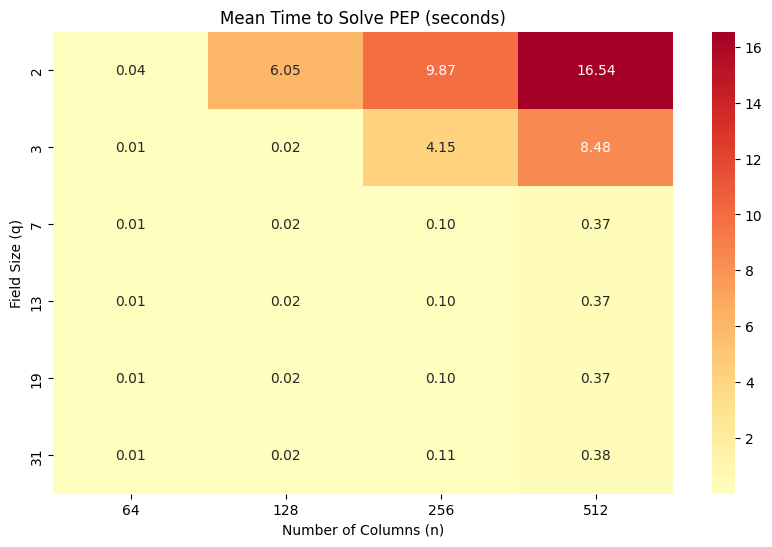

In [50]:
pivot_time = df_results.pivot_table(index='q_field', columns='n_cols', values='time_seconds', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0)
plt.title("Mean Time to Solve PEP (seconds)")
plt.xlabel("Number of Columns (n)")
plt.ylabel("Field Size (q)")
plt.show()

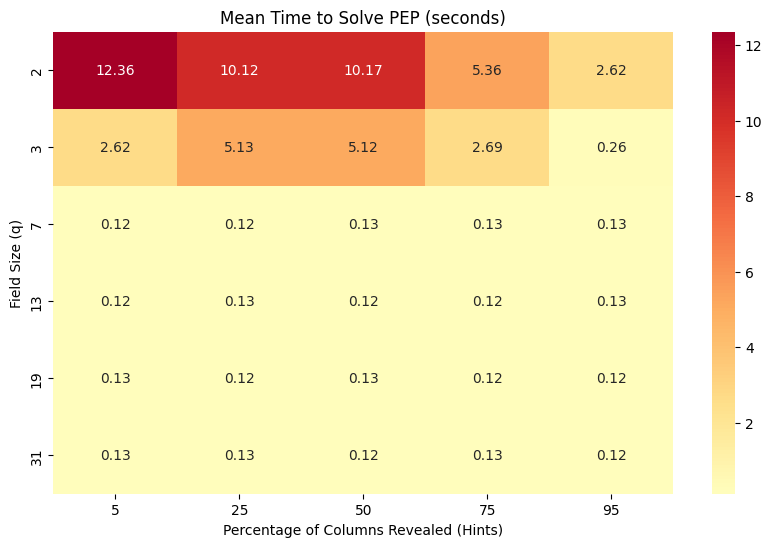

In [51]:
pivot_time = df_results.pivot_table(index='q_field', columns='hints_pct', values='time_seconds', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0)
plt.title("Mean Time to Solve PEP (seconds)")
plt.xlabel("Percentage of Columns Revealed (Hints)")
plt.ylabel("Field Size (q)")
plt.show()

/var/folders/dj/ljhjywgx7050wg5x_690yv1c0000gn/T/ipykernel_10342/1317677550.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


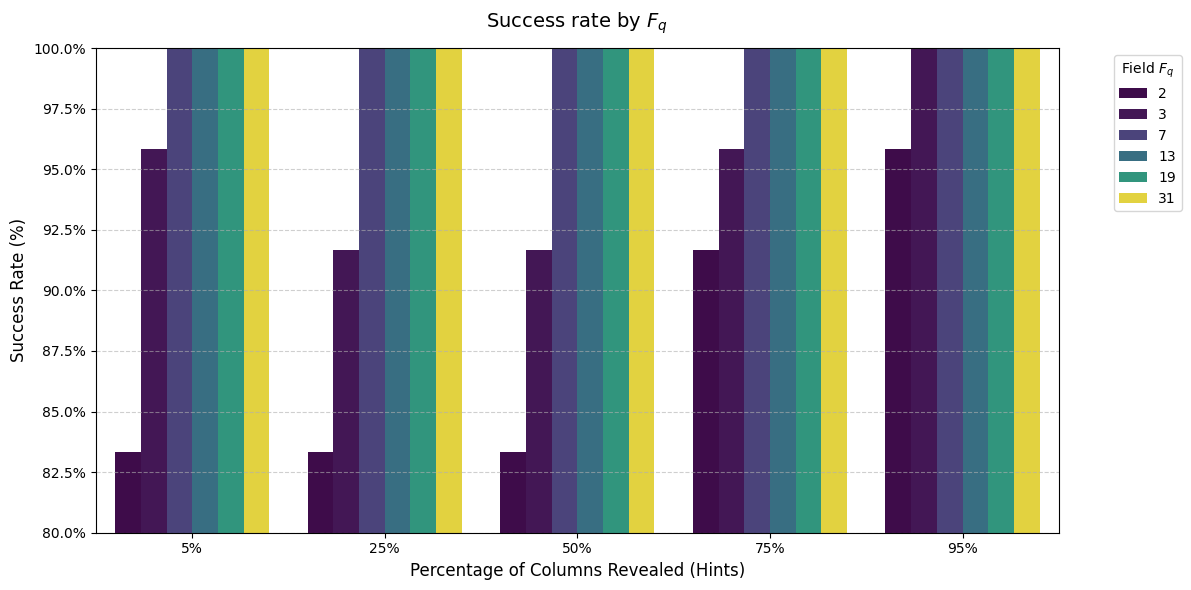

In [43]:
df_results['hints_pct'] = np.ceil(df_results['n_hints'] / df_results['total_cols'] * 100).astype(int)
if 94 in df_results['hints_pct'].values:
    df_results.loc[df_results['hints_pct'] == 94, 'hints_pct'] = 95

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_results, 
    x='hints_pct', 
    y='success', 
    hue='q_field', 
    palette='viridis',
    errorbar=None
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.8, 1.0)

labels = [f'{int(float(l.get_text()))}%' for l in ax.get_xticklabels()]
ax.set_xticklabels(labels)

plt.title("Success rate by $F_q$", fontsize=14, pad=15)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.xlabel("Percentage of Columns Revealed (Hints)", fontsize=12)
plt.legend(title='Field $F_q$', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/dj/ljhjywgx7050wg5x_690yv1c0000gn/T/ipykernel_10342/1992287915.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


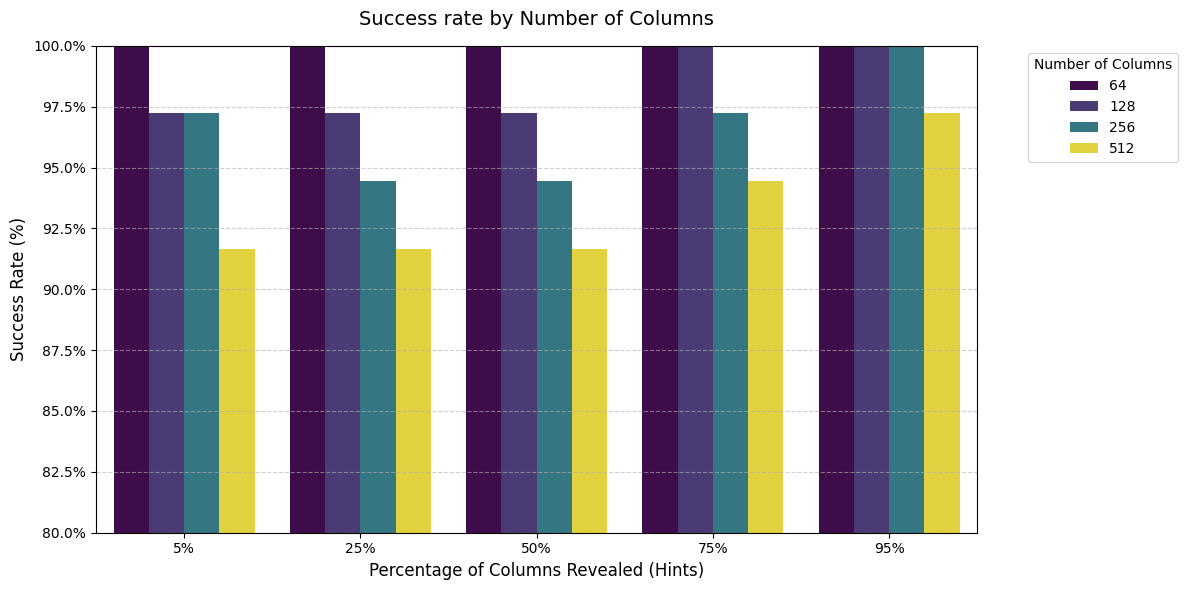

In [44]:
df_results['hints_pct'] = np.ceil(df_results['n_hints'] / df_results['total_cols'] * 100).astype(int)

if 94 in df_results['hints_pct'].values:
    df_results.loc[df_results['hints_pct'] == 94, 'hints_pct'] = 95

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_results, 
    x='hints_pct', 
    y='success', 
    hue='n_cols', 
    palette='viridis',
    errorbar=None
)

ax.set_ylim(0.8, 1.0)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

labels = [f'{int(float(l.get_text()))}%' for l in ax.get_xticklabels()]
ax.set_xticklabels(labels)

plt.title("Success rate by Number of Columns", fontsize=14, pad=15)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.xlabel("Percentage of Columns Revealed (Hints)", fontsize=12)
plt.legend(title='Number of Columns', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()